In [1]:
import hbsir
hbsir.setup(years=[1395])
table_1395 = hbsir.load_table("Expenditures", years=[1395])
print(table_1395.head())
table_1395 = hbsir.add_attribute(table_1395, name="Province")
table_1395 = hbsir.add_attribute(table_1395, name="County")
table_1395 = hbsir.add_attribute(table_1395, name="Urban_Rural")
hhinc_1395 = hbsir.load_table("employment_income", years=[1395])
members_1395 = hbsir.load_table("members_properties", years=[1395])

   Year           ID Table_Name  Commodity_Code Provision_Method Amount  \
0  1395  20001010534       food           11165         Purchase   24.0   
1  1395  20001010525       food           11112         Purchase  240.0   
2  1395  20001010525       food           11143         Purchase   24.0   
3  1395  20001010525       food           11151         Purchase  360.0   
4  1395  20001010525       food           11153         Purchase   24.0   

      Price  Gross_Expenditure  Net_Expenditure  
0   20000.0           480000.0         480000.0  
1  100000.0         24000000.0       24000000.0  
2   20000.0           480000.0         480000.0  
3   16000.0          5760000.0        5760000.0  
4   45000.0          1080000.0        1080000.0  


C:\Users\tadbirsabz\AppData\Local\Temp\ipykernel_5168\2193095105.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)


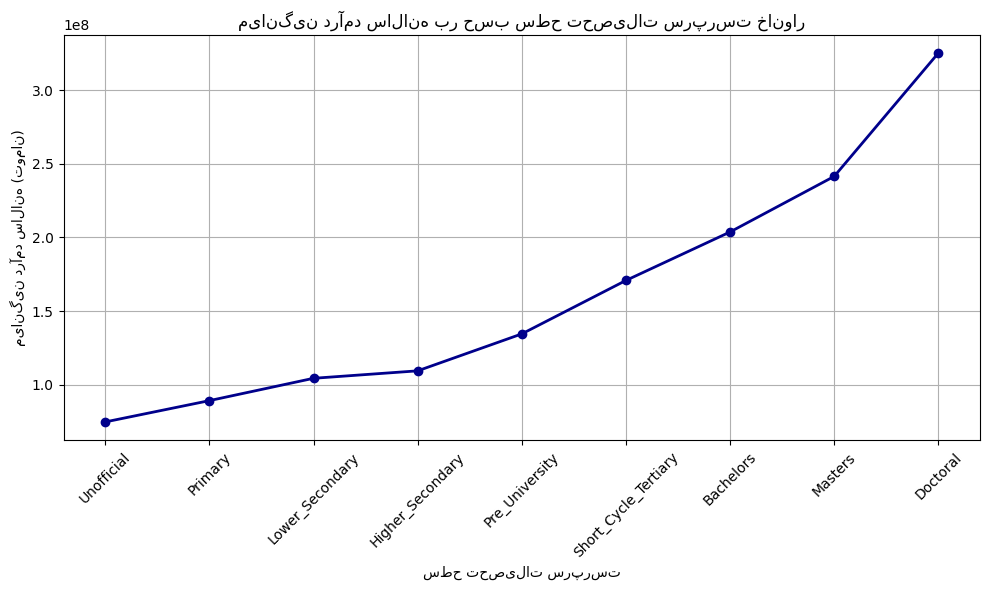

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# لیست مرتب‌شده سطح تحصیلات
valid_levels = [
    "Unofficial",             
    "Primary",                
    "Lower_Secondary",        
    "Higher_Secondary",       
    "Pre_University",         
    "Short_Cycle_Tertiary",   
    "Bachelors",              
    "Masters",                
    "Doctoral"                
]

# فیلتر فقط سرپرست‌ها با سطح تحصیلات معتبر
df_1395 = members_1395[(members_1395["Member_Number"] == 1) & (members_1395["Education_Level"].isin(valid_levels))].copy()

# تبدیل به نوع مرتب Categorical
df_1395["Education_Level"] = pd.Categorical(df_1395["Education_Level"], categories=valid_levels, ordered=True)

# اضافه کردن درآمد سرپرست‌ها از hhinc
df_1395 = df_1395.merge(
    hhinc_1395[hhinc_1395["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
    on="ID",
    how="left"
)

# حذف ردیف‌هایی که درآمد ندارن
df_1395 = df_1395.dropna(subset=["Annual_Continuous_Income"])

# محاسبه میانگین درآمد برای هر سطح تحصیل
mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)

# 📈 رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(mean_income_1395.index, mean_income_1395.values, marker='o', color='darkblue', linewidth=2)
plt.xlabel("سطح تحصیلات سرپرست")
plt.ylabel("میانگین درآمد سالانه (تومان)")
plt.title("میانگین درآمد سالانه بر حسب سطح تحصیلات سرپرست خانوار")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.251
Model:                                  OLS   Adj. R-squared:                  0.251
Method:                       Least Squares   F-statistic:                     2294.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              12:43:15   Log-Likelihood:            -2.6759e+05
No. Observations:                     13698   AIC:                         5.352e+05
Df Residuals:                         13695   BIC:                         5.352e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

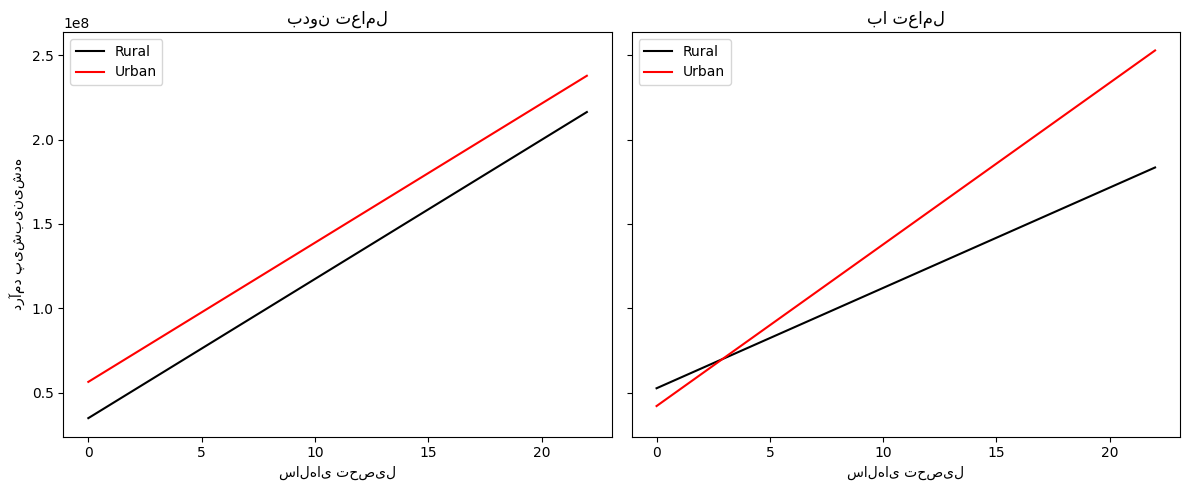

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ----------------------
# 1. نگاشت سطح تحصیلات به سال تحصیل
# ----------------------
edu_map = {
    "Unofficial": 0,
    "Primary": 5,
    "Lower_Secondary": 8,
    "Higher_Secondary": 12,
    "Pre_University": 13,
    "Short_Cycle_Tertiary": 14,
    "Bachelors": 16,
    "Masters": 18,
    "Doctoral": 22
}

# فیلتر فقط سرپرست‌ها با سطح تحصیلات معتبر
df = members_1395[(members_1395["Member_Number"] == 1) & 
             (members_1395["Education_Level"].isin(valid_levels))].copy()

# افزودن سال تحصیل
# افزودن سال تحصیل و تبدیل به عدد
df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)


# اضافه کردن درآمد
df = df.merge(
    hhinc_1395[hhinc_1395["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
    on="ID", how="left"
)

# اضافه کردن شهری/روستایی
urban_rural = table_1395[["ID", "Urban_Rural"]].drop_duplicates()
df = df.merge(urban_rural, on="ID", how="left")

# حذف ردیف‌هایی که درآمد ندارند
df = df.dropna(subset=["Annual_Continuous_Income"])

# تبدیل Urban_Rural به ۰ و ۱
df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)

# ----------------------
# 2. مدل‌سازی
# ----------------------
# مدل بدون تعامل
model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()

# مدل با تعامل
model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()

print("\n---- مدل بدون تعامل ----")
print(model_no_inter.summary())

print("\n---- مدل با تعامل ----")
print(model_inter.summary())

# ----------------------
# 3. رسم نمودار
# ----------------------
# بازه تحصیلات برای پیش‌بینی
years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)

plot_df = pd.DataFrame({
    "Years_Edu": np.tile(years_range, 2),
    "Urban": np.repeat([0, 1], len(years_range))
})

# پیش‌بینی
plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
plot_df["pred_inter"] = model_inter.predict(plot_df)

# رسم
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# بدون تعامل
for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
    subset = plot_df[plot_df["Urban"] == u]
    axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)

axes[0].set_title("بدون تعامل")
axes[0].set_xlabel("سال‌های تحصیل")
axes[0].set_ylabel("درآمد پیش‌بینی‌شده")
axes[0].legend()

# با تعامل
for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
    subset = plot_df[plot_df["Urban"] == u]
    axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)

axes[1].set_title("با تعامل")
axes[1].set_xlabel("سال‌های تحصیل")
axes[1].legend()

plt.tight_layout()
plt.show()



=== پردازش سال 1396 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.275
Model:                                  OLS   Adj. R-squared:                  0.275
Method:                       Least Squares   F-statistic:                     2575.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:13:29   Log-Likelihood:            -2.6686e+05
No. Observations:                     13552   AIC:                         5.337e+05
Df Residuals:                         13549   BIC:                         5.337e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

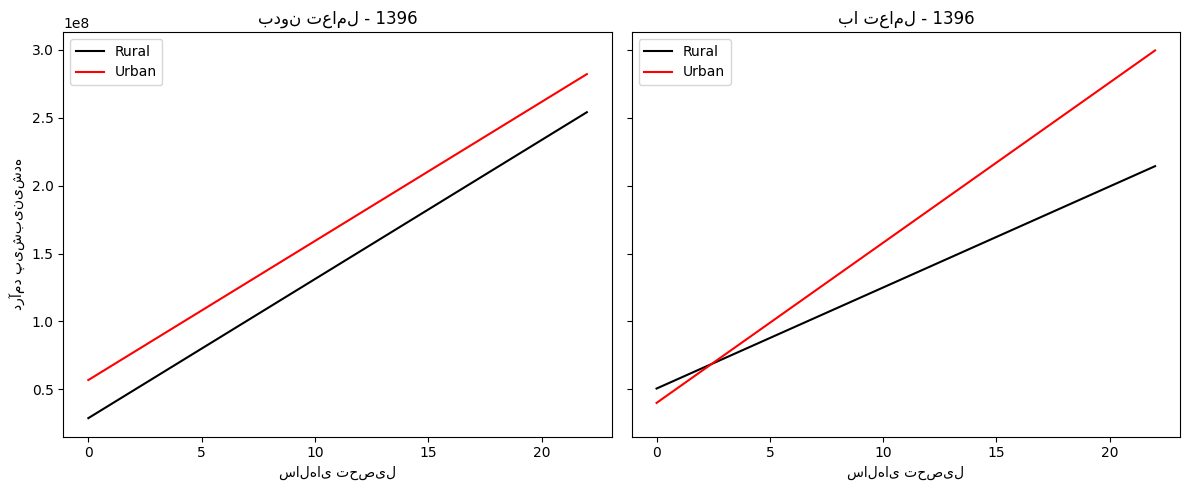


=== پردازش سال 1397 ===
⚠ خطا در پردازش سال 1397: File is not a zip file

=== پردازش سال 1398 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.247
Model:                                  OLS   Adj. R-squared:                  0.246
Method:                       Least Squares   F-statistic:                     2306.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:14:02   Log-Likelihood:            -2.8322e+05
No. Observations:                     14098   AIC:                         5.664e+05
Df Residuals:                         14095   BIC:                         5.665e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    

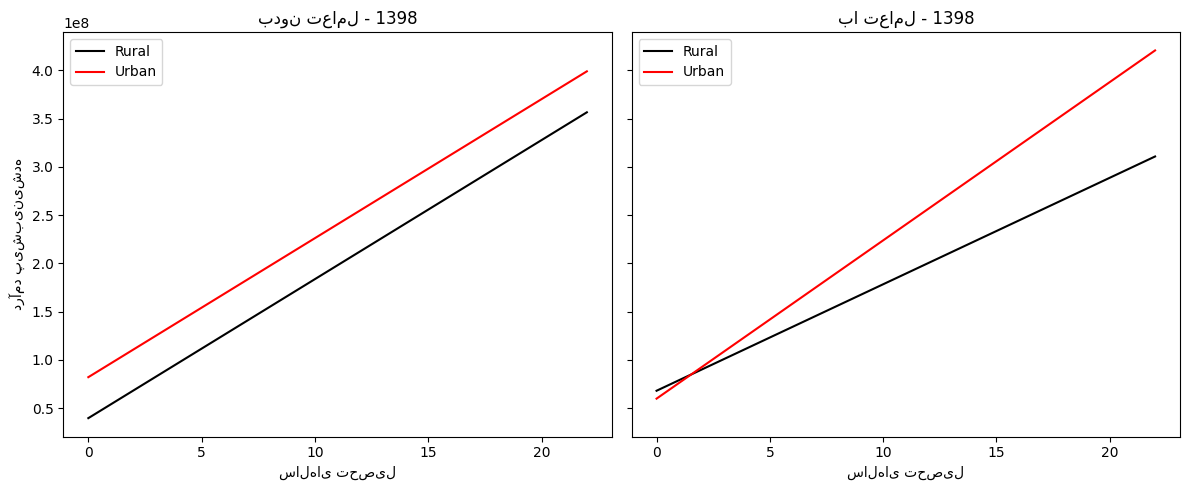


=== پردازش سال 1399 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.241
Model:                                  OLS   Adj. R-squared:                  0.241
Method:                       Least Squares   F-statistic:                     2273.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:14:33   Log-Likelihood:            -2.9233e+05
No. Observations:                     14340   AIC:                         5.847e+05
Df Residuals:                         14337   BIC:                         5.847e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

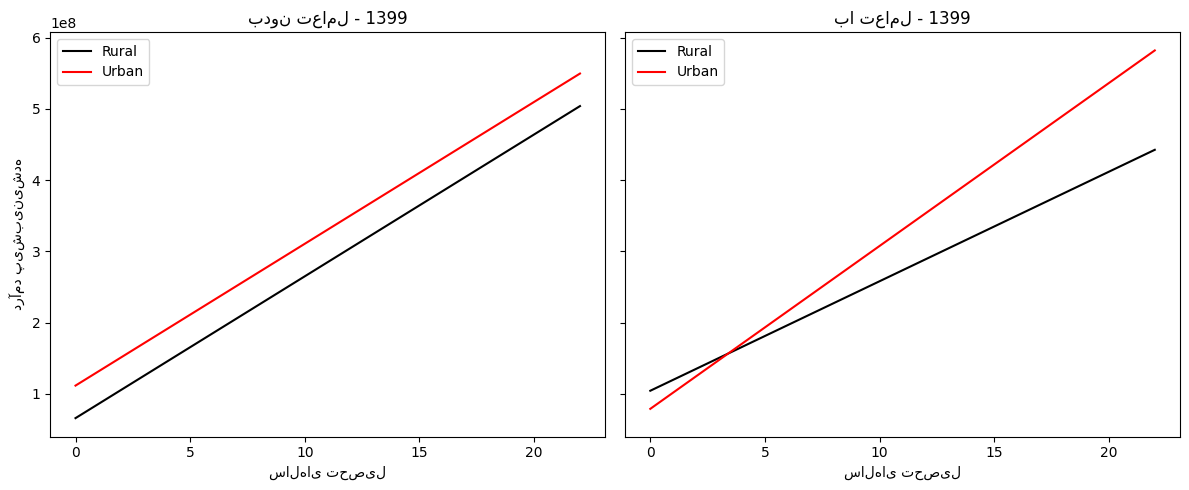


=== پردازش سال 1400 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.214
Model:                                  OLS   Adj. R-squared:                  0.214
Method:                       Least Squares   F-statistic:                     1947.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:15:06   Log-Likelihood:            -2.9751e+05
No. Observations:                     14308   AIC:                         5.950e+05
Df Residuals:                         14305   BIC:                         5.951e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

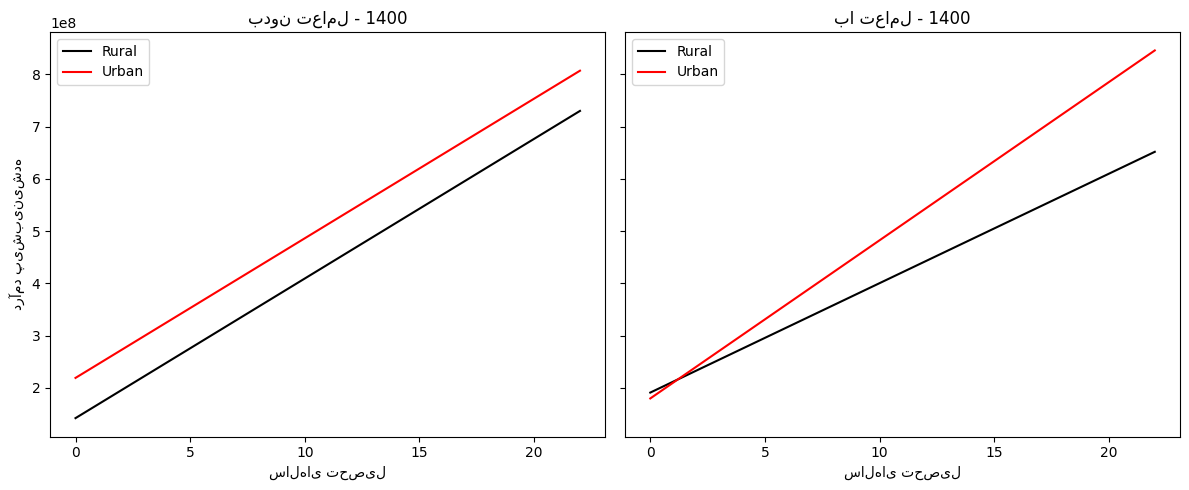


=== پردازش سال 1401 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.171
Model:                                  OLS   Adj. R-squared:                  0.171
Method:                       Least Squares   F-statistic:                     1436.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:15:38   Log-Likelihood:            -2.9557e+05
No. Observations:                     13946   AIC:                         5.911e+05
Df Residuals:                         13943   BIC:                         5.912e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

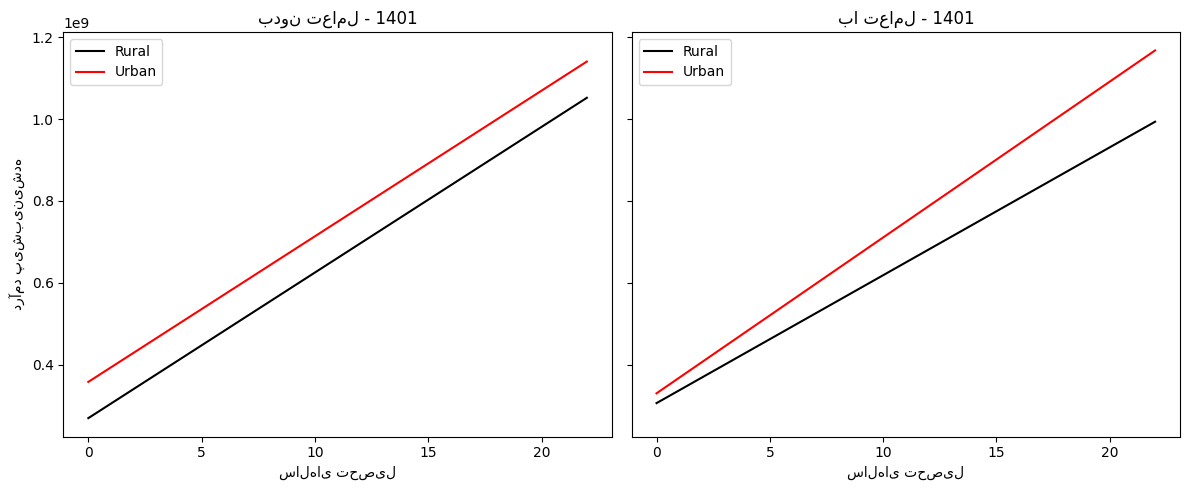

In [5]:
for year in range(1396, 1402):
    print(f"\n=== پردازش سال {year} ===")
    try:
        # ---------- بارگذاری داده‌ها ----------
        hbsir.setup(years=[year])
        table = hbsir.load_table("Expenditures", years=[year])
        table = hbsir.add_attribute(table, name="Province")
        table = hbsir.add_attribute(table, name="County")
        table = hbsir.add_attribute(table, name="Urban_Rural")

        hhinc = hbsir.load_table("employment_income", years=[year])
        members = hbsir.load_table("members_properties", years=[year])

        # ---------- پردازش ----------
        df = members[(members["Member_Number"] == 1) & 
                     (members["Education_Level"].isin(valid_levels))].copy()
        df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)

        df = df.merge(
            hhinc[hhinc["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
            on="ID", how="left"
        )

        urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
        df = df.merge(urban_rural, on="ID", how="left")

        df = df.dropna(subset=["Annual_Continuous_Income"])
        df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)

        # ---------- مدل ----------
        model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
        model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()

        print("\n---- مدل بدون تعامل ----")
        print(model_no_inter.summary())

        print("\n---- مدل با تعامل ----")
        print(model_inter.summary())

        # ---------- نمودار ----------
        years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
        plot_df = pd.DataFrame({
            "Years_Edu": np.tile(years_range, 2),
            "Urban": np.repeat([0, 1], len(years_range))
        })
        plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
        plot_df["pred_inter"] = model_inter.predict(plot_df)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
            subset = plot_df[plot_df["Urban"] == u]
            axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
            axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)

        axes[0].set_title(f"بدون تعامل - {year}")
        axes[0].set_xlabel("سال‌های تحصیل")
        axes[0].set_ylabel("درآمد پیش‌بینی‌شده")
        axes[0].legend()

        axes[1].set_title(f"با تعامل - {year}")
        axes[1].set_xlabel("سال‌های تحصیل")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠ خطا در پردازش سال {year}: {e}")
        continue



=== پردازش سال 1396 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.275
Model:                                  OLS   Adj. R-squared:                  0.275
Method:                       Least Squares   F-statistic:                     2575.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:43:44   Log-Likelihood:            -2.6686e+05
No. Observations:                     13552   AIC:                         5.337e+05
Df Residuals:                         13549   BIC:                         5.337e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

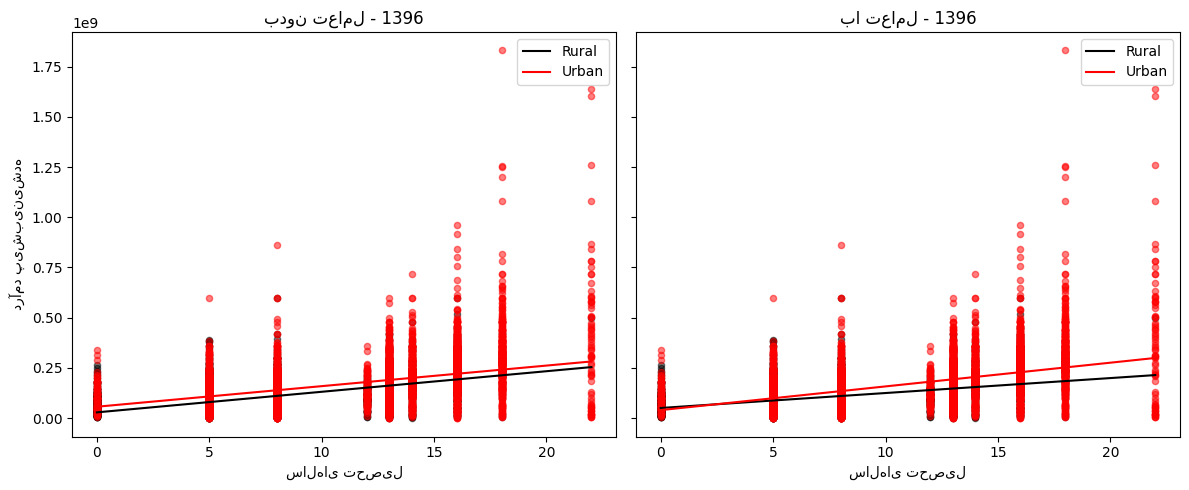


=== پردازش سال 1397 ===
⚠ خطا در پردازش سال 1397: File is not a zip file

=== پردازش سال 1398 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.247
Model:                                  OLS   Adj. R-squared:                  0.246
Method:                       Least Squares   F-statistic:                     2306.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:44:14   Log-Likelihood:            -2.8322e+05
No. Observations:                     14098   AIC:                         5.664e+05
Df Residuals:                         14095   BIC:                         5.665e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    

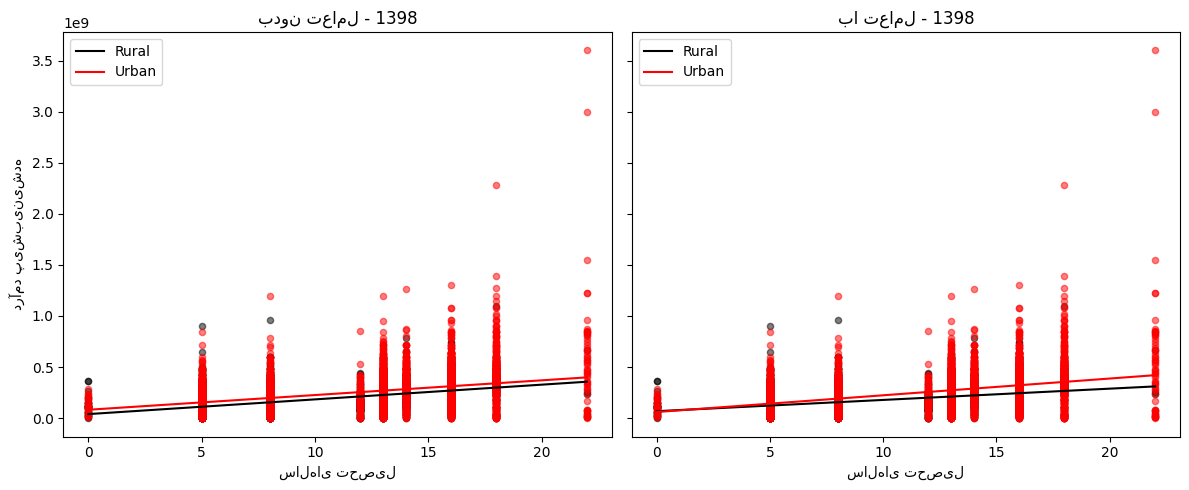


=== پردازش سال 1399 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.241
Model:                                  OLS   Adj. R-squared:                  0.241
Method:                       Least Squares   F-statistic:                     2273.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:44:46   Log-Likelihood:            -2.9233e+05
No. Observations:                     14340   AIC:                         5.847e+05
Df Residuals:                         14337   BIC:                         5.847e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

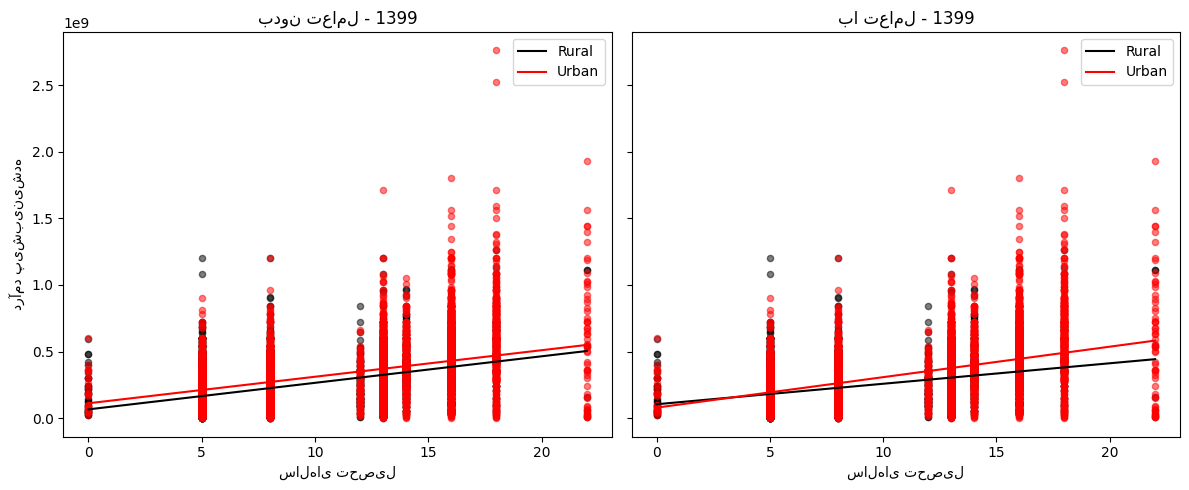


=== پردازش سال 1400 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.214
Model:                                  OLS   Adj. R-squared:                  0.214
Method:                       Least Squares   F-statistic:                     1947.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:45:16   Log-Likelihood:            -2.9751e+05
No. Observations:                     14308   AIC:                         5.950e+05
Df Residuals:                         14305   BIC:                         5.951e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

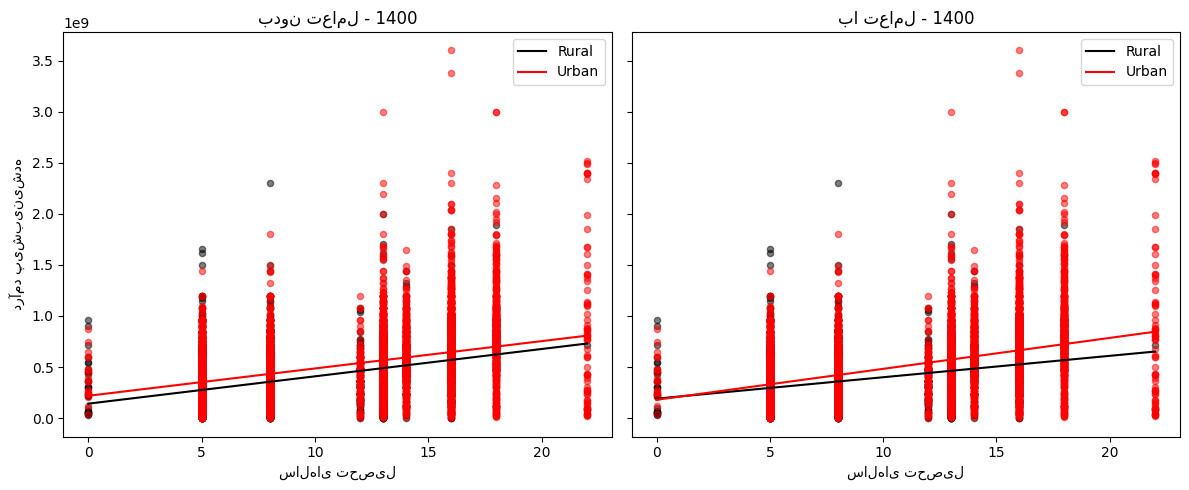


=== پردازش سال 1401 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.171
Model:                                  OLS   Adj. R-squared:                  0.171
Method:                       Least Squares   F-statistic:                     1436.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:45:43   Log-Likelihood:            -2.9557e+05
No. Observations:                     13946   AIC:                         5.911e+05
Df Residuals:                         13943   BIC:                         5.912e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

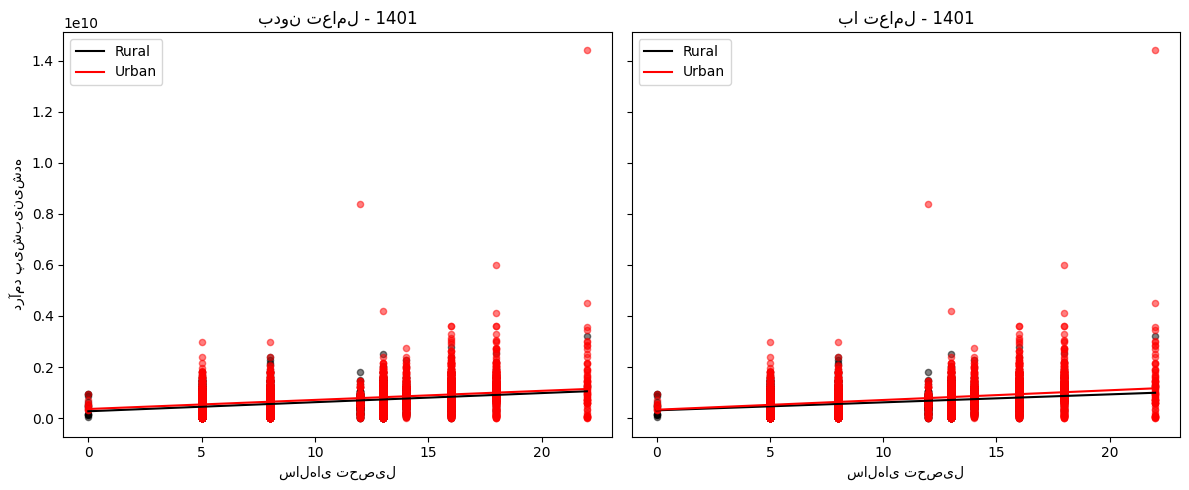

In [12]:
import hbsir
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

valid_levels = [
    "Unofficial", "Primary", "Lower_Secondary", "Higher_Secondary",
    "Pre_University", "Short_Cycle_Tertiary", "Bachelors", "Masters", "Doctoral"
]

edu_map = {
    "Unofficial": 0, "Primary": 5, "Lower_Secondary": 8, "Higher_Secondary": 12,
    "Pre_University": 13, "Short_Cycle_Tertiary": 14, "Bachelors": 16,
    "Masters": 18, "Doctoral": 22
}

for year in range(1396, 1402):
    print(f"\n=== پردازش سال {year} ===")
    try:
        # --- بارگذاری داده‌ها ---
        hbsir.setup(years=[year])
        table = hbsir.load_table("Expenditures", years=[year])
        table = hbsir.add_attribute(table, name="Province")
        table = hbsir.add_attribute(table, name="County")
        table = hbsir.add_attribute(table, name="Urban_Rural")

        hhinc = hbsir.load_table("employment_income", years=[year])
        members = hbsir.load_table("members_properties", years=[year])

        # --- فیلتر سرپرست‌ها ---
        df = members[(members["Member_Number"] == 1) &
                     (members["Education_Level"].isin(valid_levels))].copy()
        df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)

        # اضافه کردن درآمد
        df = df.merge(
            hhinc[hhinc["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
            on="ID", how="left"
        )

        # اضافه کردن شهری/روستایی
        urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
        df = df.merge(urban_rural, on="ID", how="left")

        # حذف ردیف‌های بدون درآمد
        df = df.dropna(subset=["Annual_Continuous_Income"])

        # تبدیل Urban_Rural به ۰ و ۱
        df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)

        # --- مدل‌سازی ---
        model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
        model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()

        print("\n---- مدل بدون تعامل ----")
        print(model_no_inter.summary())

        print("\n---- مدل با تعامل ----")
        print(model_inter.summary())

        # --- داده‌های پیش‌بینی ---
        years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
        plot_df = pd.DataFrame({
            "Years_Edu": np.tile(years_range, 2),
            "Urban": np.repeat([0, 1], len(years_range))
        })
        plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
        plot_df["pred_inter"] = model_inter.predict(plot_df)

        # --- رسم نمودار ---
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

        # بدون تعامل + نقاط واقعی
        for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
            # خط رگرسیون
            subset_line = plot_df[plot_df["Urban"] == u]
            axes[0].plot(subset_line["Years_Edu"], subset_line["pred_no_inter"], color=color, label=label)

            # نقاط واقعی
            subset_points = df[df["Urban"] == u]
            axes[0].scatter(subset_points["Years_Edu"], subset_points["Annual_Continuous_Income"],
                            color=color, alpha=0.5, s=20)

        axes[0].set_title(f"بدون تعامل - {year}")
        axes[0].set_xlabel("سال‌های تحصیل")
        axes[0].set_ylabel("درآمد پیش‌بینی‌شده")
        axes[0].legend()

        # با تعامل + نقاط واقعی
        for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
            subset_line = plot_df[plot_df["Urban"] == u]
            axes[1].plot(subset_line["Years_Edu"], subset_line["pred_inter"], color=color, label=label)

            subset_points = df[df["Urban"] == u]
            axes[1].scatter(subset_points["Years_Edu"], subset_points["Annual_Continuous_Income"],
                            color=color, alpha=0.5, s=20)

        axes[1].set_title(f"با تعامل - {year}")
        axes[1].set_xlabel("سال‌های تحصیل")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠ خطا در پردازش سال {year}: {e}")
        continue



=== پردازش سال 1396 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.262
Model:                                  OLS   Adj. R-squared:                  0.262
Method:                       Least Squares   F-statistic:                     2403.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              19:39:10   Log-Likelihood:            -2.6698e+05
No. Observations:                     13552   AIC:                         5.340e+05
Df Residuals:                         13549   BIC:                         5.340e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------

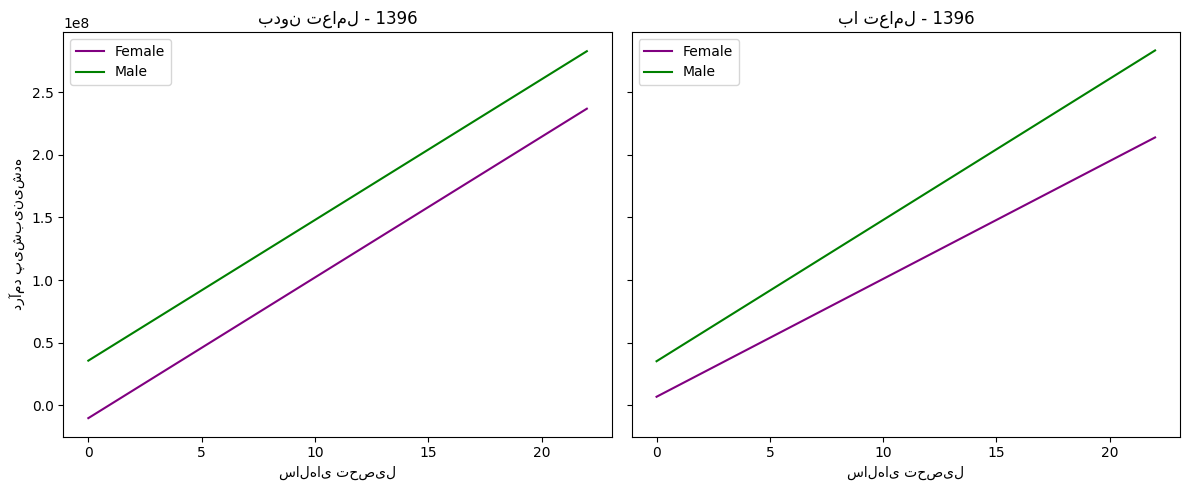


=== پردازش سال 1397 ===
⚠ خطا در پردازش سال 1397: File is not a zip file

=== پردازش سال 1398 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.231
Model:                                  OLS   Adj. R-squared:                  0.231
Method:                       Least Squares   F-statistic:                     2115.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              19:39:42   Log-Likelihood:            -2.8336e+05
No. Observations:                     14098   AIC:                         5.667e+05
Df Residuals:                         14095   BIC:                         5.668e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                         

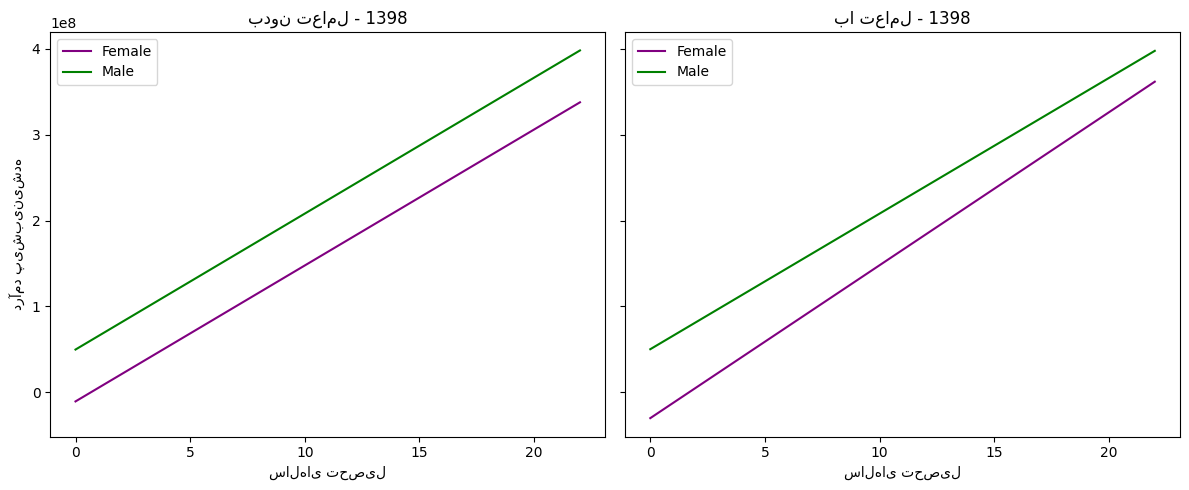


=== پردازش سال 1399 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.232
Model:                                  OLS   Adj. R-squared:                  0.232
Method:                       Least Squares   F-statistic:                     2163.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              19:40:12   Log-Likelihood:            -2.9241e+05
No. Observations:                     14340   AIC:                         5.848e+05
Df Residuals:                         14337   BIC:                         5.849e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------

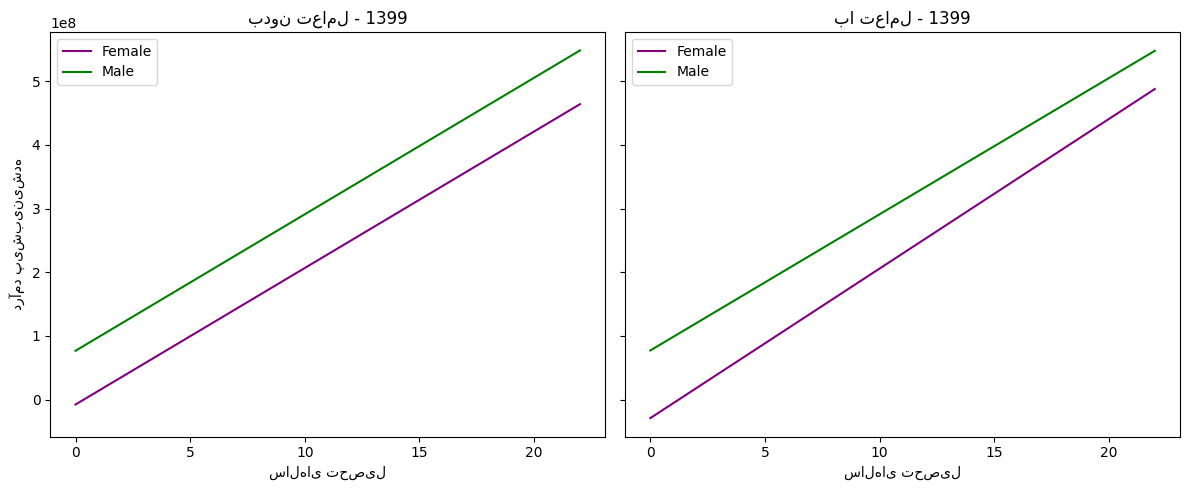


=== پردازش سال 1400 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.201
Model:                                  OLS   Adj. R-squared:                  0.201
Method:                       Least Squares   F-statistic:                     1803.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              19:40:43   Log-Likelihood:            -2.9763e+05
No. Observations:                     14308   AIC:                         5.953e+05
Df Residuals:                         14305   BIC:                         5.953e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------

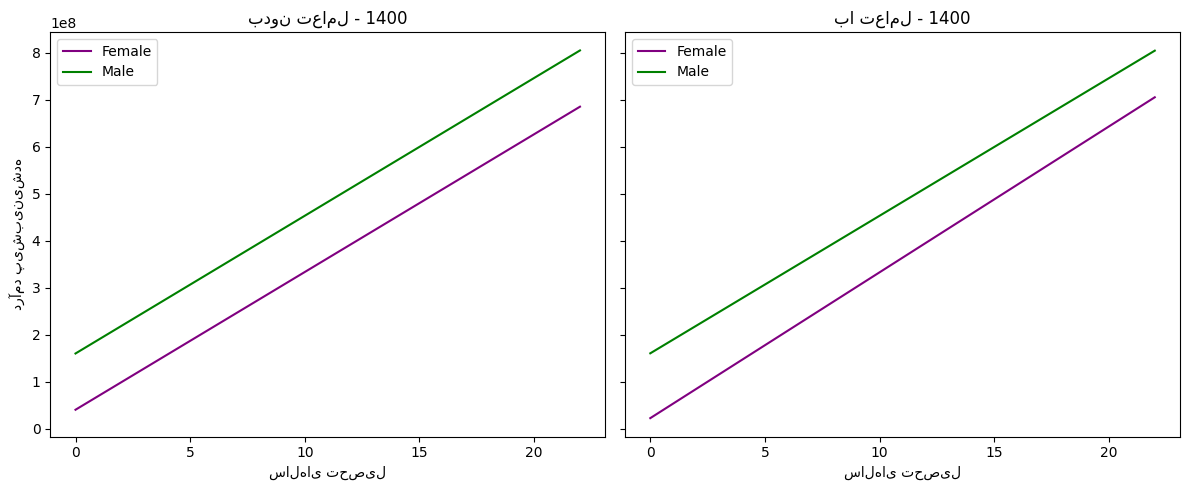


=== پردازش سال 1401 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.165
Model:                                  OLS   Adj. R-squared:                  0.165
Method:                       Least Squares   F-statistic:                     1379.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              19:41:11   Log-Likelihood:            -2.9559e+05
No. Observations:                     13945   AIC:                         5.912e+05
Df Residuals:                         13942   BIC:                         5.912e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------

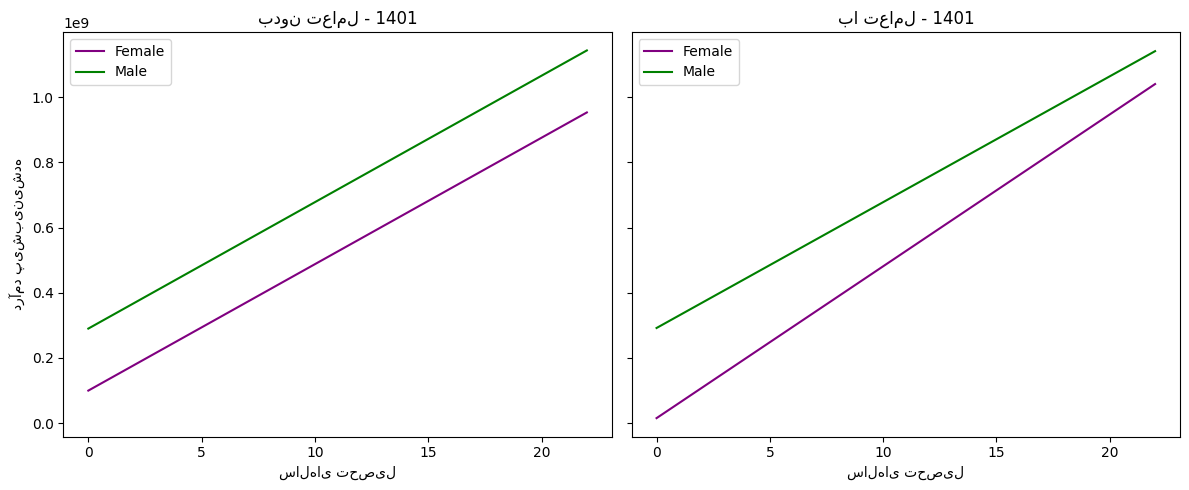

In [13]:
for year in range(1396, 1402):
    print(f"\n=== پردازش سال {year} ===")
    try:
        # ---------- بارگذاری داده‌ها ----------
        hbsir.setup(years=[year])
        table = hbsir.load_table("Expenditures", years=[year])
        table = hbsir.add_attribute(table, name="Province")
        table = hbsir.add_attribute(table, name="County")
        table = hbsir.add_attribute(table, name="Urban_Rural")  # دیگه استفاده نمیشه، ولی نگه داشتم اگر لازم شد

        hhinc = hbsir.load_table("employment_income", years=[year])
        members = hbsir.load_table("members_properties", years=[year])

        # ---------- پردازش ----------
        df = members[(members["Member_Number"] == 1) &
                     (members["Education_Level"].isin(valid_levels))].copy()
        df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)

        # اضافه کردن درآمد
        df = df.merge(
            hhinc[hhinc["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
            on="ID", how="left"
        )

        # ستون جنسیت: فرض بر اینه که ستون Gender در members هست
        # Male -> 1, Female -> 0
        df["Gender_Binary"] = df["Sex"].apply(lambda x: 1 if str(x).lower() == "male" else 0)

        # حذف ردیف‌های بدون درآمد یا بدون جنسیت
        df = df.dropna(subset=["Annual_Continuous_Income", "Gender_Binary"])

        # ---------- مدل ----------
        model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Gender_Binary", data=df).fit()
        model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Gender_Binary", data=df).fit()

        print("\n---- مدل بدون تعامل ----")
        print(model_no_inter.summary())

        print("\n---- مدل با تعامل ----")
        print(model_inter.summary())

        # ---------- نمودار ----------
        years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
        plot_df = pd.DataFrame({
            "Years_Edu": np.tile(years_range, 2),
            "Gender_Binary": np.repeat([0, 1], len(years_range))
        })
        plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
        plot_df["pred_inter"] = model_inter.predict(plot_df)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        for g, color, label in [(0, "purple", "Female"), (1, "green", "Male")]:
            subset = plot_df[plot_df["Gender_Binary"] == g]
            axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
            axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)

        axes[0].set_title(f"بدون تعامل - {year}")
        axes[0].set_xlabel("سال‌های تحصیل")
        axes[0].set_ylabel("درآمد پیش‌بینی‌شده")
        axes[0].legend()

        axes[1].set_title(f"با تعامل - {year}")
        axes[1].set_xlabel("سال‌های تحصیل")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠ خطا در پردازش سال {year}: {e}")
        continue


In [ ]:
import hbsir
import pandas as pd
from pandas.api.types import is_numeric_dtype

# ===== تنظیم سال‌ها =====
years = [1395]  # هر سالی که داری بگذار
hbsir.setup(years=years)

def safe_call(fn, *args, **kwargs):
    try:
        return fn(*args, **kwargs)
    except Exception as e:
        return e  # برای تشخیص وجود/عدم وجود جدول

def pretty_preview(name, years, head_n=5, sample_n=5):
    print("\n" + "="*80)
    print(f"TABLE: {name}")
    print("="*80)
    df = safe_call(hbsir.load_table, name, years=years)
    if isinstance(df, Exception):
        print(f"❌ Cannot load '{name}': {df}")
        return None
    try:
        print(f"✅ Loaded '{name}' for years={years}")
        print(f"Shape: {df.shape}")
        print("Columns:", list(df.columns))
        # نمایش چند سطر اول
        print("\n-- head() --")
        print(df.head(head_n))
        # نمایش چند سطر تصادفی
        if len(df) > sample_n:
            print("\n-- sample() --")
            print(df.sample(sample_n, random_state=42))
        # خلاصه info
        print("\n-- info() --")
        buf = []
        df.info(buf=buf)
        print("\n".join(buf) if isinstance(buf, list) else buf)
    except Exception as e:
        print(f"⚠️ Preview error for '{name}': {e}")
    return df

# 1) تلاش برای یافتن تابع داخلی فهرست جداول
candidate_listers = ["list_tables", "available_tables", "tables", "catalog", "list_table_names"]
found_tables = []

for attr in candidate_listers:
    lister = getattr(hbsir, attr, None)
    if callable(lister):
        tables = safe_call(lister)
        if not isinstance(tables, Exception) and tables:
            # اگر خروجی DataFrame یا dict بود، تبدیل به فهرست
            if isinstance(tables, (list, tuple, set)):
                found_tables = sorted(set(map(str, tables)))
            elif isinstance(tables, pd.DataFrame) and "table" in tables.columns:
                found_tables = sorted(set(tables["table"].astype(str).tolist()))
            elif isinstance(tables, dict):
                found_tables = sorted(set(map(str, tables.keys())))
            else:
                # fallback: تلاش برای iterable بودن
                try:
                    found_tables = sorted(set(map(str, list(tables))))
                except:
                    pass
            if found_tables:
                print("✅ Found table list via:", attr)
                break

# 2) اگر هنوز چیزی نداریم، به‌صورت پروب: نام‌های متداول
if not found_tables:
    common_names = [
        "Expenditures", "employment_income", "members_properties", "household_properties",
        "income", "incomes", "expenditures", "expenditures_food", "expenditures_nonfood",
        "durables", "housing", "rent", "assets", "consumption", "health", "education",
        "price", "prices", "utilities", "transport", "vehicle", "agriculture", "loans",
        "savings", "insurance", "medical", "food", "nonfood"
    ]
    # پروب لود
    detected = []
    for name in common_names:
        df_try = safe_call(hbsir.load_table, name, years=years)
        if not isinstance(df_try, Exception):
            detected.append(name)
    found_tables = detected

# گزارش اولیه جدول‌ها
if found_tables:
    print("\n🗂  Discovered tables:")
    for t in found_tables:
        print(" -", t)
else:
    print("⛔️ No tables auto-discovered. If the package has docs, check exact table names. "
          "Otherwise tell me any one name that worked so I tune the probe set.")

# 3) پیش‌نمایش نمونه از هر جدول پیدا شده
for t in found_tables[:20]:  # اگر زیاد شد، محدود کن
    pretty_preview(t, years=years, head_n=5, sample_n=5)

# 4) اگر هیچ چیز پیدا نشد، نمونه‌هایی که خودت می‌دانی را مستقیم نشان بده:
# pretty_preview("Expenditures", years=[1395])
# pretty_preview("employment_income", years=[1395])
# pretty_preview("members_properties", years=[1395])


ساخت شاخص برای قدرت خرید

In [20]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import hbsir

# -------------------------
# 1) Load & basic enrich
# -------------------------
hbsir.setup(years=[1395])

exp = hbsir.load_table("Expenditures", years=[1395])
exp = hbsir.add_attribute(exp, name="Province")
exp = hbsir.add_attribute(exp, name="County")
exp = hbsir.add_attribute(exp, name="Urban_Rural")

inc = hbsir.load_table("employment_income", years=[1395])
mem = hbsir.load_table("members_properties", years=[1395])

# اگر نام ستون شناسه خانوار متفاوت است، اینجا یکسان‌سازی کن:
hh_key = "ID"  # فرض: ستون شناسه خانوار همین است

# -------------------------
# 2) Clean basics
# -------------------------
# تبدیل برخی ستون‌ها به عددی (در صورت وجود مقادیر متنی)
for col in ["Amount", "Price", "Gross_Expenditure", "Net_Expenditure"]:
    if col in exp.columns:
        exp[col] = pd.to_numeric(exp[col], errors="coerce")

# تیتر غذا و مسکن را مشخص کن:
# - اگر ستون Table_Name مثل نمونه‌ی تو وجود دارد و مقادیرش 'food' برای خوراک است
is_food = (exp.get("Table_Name", pd.Series(index=exp.index, dtype=object)) == "food")

# اگر کدهای مسکن/اجاره را داری، اینجا مشخص کن:
# مثلا Commodity_Code برای اجاره/مسکن:
is_housing = exp["Table_Name"] == "home"

# -------------------------
# 3) Regional price index (Province × Urban_Rural)
# -------------------------
# ایده: برای هر قلم، میانه قیمت ملی را بگیر؛ سپس برای هر منطقه، نسبت میانه قیمت منطقه به ملی را بگیر
# و در نهایت شاخص قیمت منطقه را میانه این نسبت‌ها در سبد مشترک قرار دهیم.
# برای پایداری، اقلام با تعداد مشاهده کم را حذف می‌کنیم.

# فقط اقلامی که هم قیمت و هم مبلغ دارند
price_df = exp.dropna(subset=["Price", "Commodity_Code"]).copy()

# میانه قیمت ملی هر قلم
nat_price = (price_df
             .groupby("Commodity_Code")["Price"]
             .median()
             .rename("Nat_MedPrice"))

price_df = price_df.merge(nat_price, on="Commodity_Code", how="left")
price_df = price_df[(price_df["Nat_MedPrice"] > 0) & (price_df["Price"] > 0)]
price_df["RelPrice"] = price_df["Price"] / price_df["Nat_MedPrice"]

# منطقه = Province × Urban_Rural
price_df["Region"] = price_df["Province"].astype(str) + " | " + price_df["Urban_Rural"].astype(str)

# برای هر Region×Commodity_Code نسبت میانه قیمت
reg_item_rel = (price_df
                .groupby(["Region", "Commodity_Code"])["RelPrice"]
                .median()
                .reset_index())

# برای ساخت شاخص منطقه‌ای، میانه بین اقلامِ با داده مشترک
reg_pindex = (reg_item_rel
              .groupby("Region")["RelPrice"]
              .median()
              .rename("Region_PriceIndex")
              .reset_index())

# اگر خواستی وزن‌دهی کنی، می‌تونی به‌جای میانه، متوسط موزون با سهم هزینه ملی کار کنی.

# به exp وصل کن تا هر ردیف خرج، شاخص منطقه‌اش را داشته باشد
exp["Region"] = exp["Province"].astype(str) + " | " + exp["Urban_Rural"].astype(str)
exp = exp.merge(reg_pindex, on="Region", how="left")

# اگر شاخصی نبود (NaN)، 1 بگذار
exp["Region_PriceIndex"] = exp["Region_PriceIndex"].fillna(1.0)

# -------------------------
# 4) Household-level aggregation (real expenditures)
# -------------------------
# مخارج واقعی = Net_Expenditure / Region_PriceIndex  (اگر Net نیست، از Gross استفاده کن)
exp["Use_Exp"] = exp["Net_Expenditure"].fillna(exp["Gross_Expenditure"])
exp["Real_Exp"] = exp["Use_Exp"] / exp["Region_PriceIndex"]

# مجموع مخارج خانوار
hh_exp = exp.groupby(hh_key, as_index=False).agg(
    total_exp=("Use_Exp", "sum"),
    real_total_exp=("Real_Exp", "sum"),
    food_exp=("Use_Exp", lambda s: s[is_food.loc[s.index]].sum() if len(s)>0 else 0.0),
    housing_exp=("Use_Exp", lambda s: s[is_housing.loc[s.index]].sum() if len(s)>0 else 0.0)
)

# سهم‌ها
hh_exp["food_share"] = np.where(hh_exp["total_exp"]>0, hh_exp["food_exp"]/hh_exp["total_exp"], np.nan)
hh_exp["rent_burden"] = np.where(hh_exp["total_exp"]>0, hh_exp["housing_exp"]/hh_exp["total_exp"], np.nan)

# -------------------------
# 5) Income aggregation (and real income via same region index)
# -------------------------
# در جدول درآمد ممکن است ستون‌ها متفاوت باشند. چند سناریو:
# - اگر ستونی مانند 'Total_Income' یا 'Net_Income' داری، همان را بگیر.
# - اگر پراکنده است، کل ستون‌های عددی را جمع کن (به جز سال/شناسه).
inc = inc.copy()

from pandas.api.types import is_numeric_dtype

num_cols = [c for c in inc.columns if c not in [hh_key, "Year"] and is_numeric_dtype(inc[c])]

if len(num_cols) == 0:
    # اگر ستونی عددی پیدا نشد، این خط را با ستون صحیحت جایگزین کن:
    num_cols = []

hh_inc = inc.groupby(hh_key, as_index=False)[num_cols].sum() if num_cols else pd.DataFrame(columns=[hh_key, "income_total"])
if not num_cols:
    hh_inc["income_total"] = np.nan
else:
    hh_inc["income_total"] = hh_inc[num_cols].sum(axis=1)

# پیوند برای دریافت Region_PriceIndex خانوار (از جدول exp)
hh_region = exp[[hh_key, "Region"]].drop_duplicates()
hh_region = hh_region.merge(reg_pindex, on="Region", how="left").fillna({"Region_PriceIndex":1.0})

hh_inc = hh_inc.merge(hh_region[[hh_key, "Region_PriceIndex"]], on=hh_key, how="left")
hh_inc["Region_PriceIndex"] = hh_inc["Region_PriceIndex"].fillna(1.0)
hh_inc["real_income"] = hh_inc["income_total"] / hh_inc["Region_PriceIndex"]

# -------------------------
# 6) Household size & OECD equivalence
# -------------------------
# از جدول اعضا شمارش کن. اگر ستون Age داری، کودک را <14 در نظر بگیر.
size = mem.groupby(hh_key).size().rename("hh_size").reset_index()

if "Age" in mem.columns:
    tmp = mem[[hh_key, "Age"]].copy()
    tmp["is_child"] = (pd.to_numeric(tmp["Age"], errors="coerce") < 14).astype("int")
    children = tmp.groupby(hh_key)["is_child"].sum().rename("n_children").reset_index()
    demo = size.merge(children, on=hh_key, how="left").fillna({"n_children":0})
else:
    # اگر سن نداری، کودک=0 بگیر
    demo = size.copy()
    demo["n_children"] = 0

demo["n_adults"] = demo["hh_size"] - demo["n_children"]
demo.loc[demo["n_adults"]<0, "n_adults"] = 0

# OECD equivalence scale
demo["eq_size"] = 1 + 0.5*np.maximum(demo["n_adults"]-1, 0) + 0.3*demo["n_children"]
demo.loc[demo["eq_size"]<=0, "eq_size"] = demo["hh_size"].replace(0, 1)

# -------------------------
# 7) Merge all & build features
# -------------------------
df = hh_exp.merge(hh_inc[[hh_key, "income_total", "real_income"]], on=hh_key, how="left")
df = df.merge(demo[[hh_key, "hh_size", "eq_size"]], on=hh_key, how="left")

# سرانه معادل‌سازی‌شده (واقعی)
df["real_exp_pc"] = df["real_total_exp"] / df["eq_size"]
df["real_inc_pc"] = df["real_income"] / df["eq_size"]

# لاگ‌ها (پیشگیری از صفر/منفی)
for col in ["real_exp_pc", "real_inc_pc"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

df["log_real_exp_pc"] = np.log(df["real_exp_pc"].clip(lower=1))  # اگر خیلی کوچک است، 1 بگذار
df["log_real_inc_pc"] = np.log(df["real_inc_pc"].clip(lower=1))

# تمیزکاری سهم‌ها
for col in ["food_share", "rent_burden"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").clip(lower=0, upper=1)

# -------------------------
# 8) Baseline PPI (ساده)
# -------------------------
# استانداردسازی لاگ مخارج واقعی سرانه
baseline = df[["log_real_exp_pc"]].copy()
baseline_std = (baseline - baseline.mean())/baseline.std(ddof=0)
df["PPI_baseline"] = baseline_std["log_real_exp_pc"]

# -------------------------
# 9) Composite PPI via PCA
# -------------------------
feature_cols = ["log_real_exp_pc", "log_real_inc_pc"]
if "food_share" in df.columns:
    df["one_minus_food"] = 1 - df["food_share"]
    feature_cols.append("one_minus_food")
if "rent_burden" in df.columns and df["rent_burden"].notna().any():
    df["one_minus_rent"] = 1 - df["rent_burden"]
    feature_cols.append("one_minus_rent")

X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())  # یا هر استراتژی دلخواه

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA(n_components=1, random_state=42)
df["PPI_pca"] = pca.fit_transform(X_std).ravel()

# نرمال‌سازی به zscore برای خوانایی
df["PPI_pca_z"] = (df["PPI_pca"] - df["PPI_pca"].mean()) / df["PPI_pca"].std(ddof=0)

# -------------------------
# 10) خروجی نهایی
# -------------------------
out_cols = [hh_key, "Province", "Urban_Rural", "hh_size", "eq_size",
            "real_total_exp", "real_income", "real_exp_pc", "real_inc_pc",
            "food_share", "rent_burden", "PPI_baseline", "PPI_pca_z"]

# الحاق Province/Urban_Rural از exp
hh_geo = exp[[hh_key, "Province", "Urban_Rural"]].drop_duplicates()
res = df.merge(hh_geo, on=hh_key, how="left")

res_final = res[out_cols].drop_duplicates()
res_final = res_final.sort_values("PPI_pca_z", ascending=False)

print(res_final.head(10))
# res_final.to_csv("ppi_1395.csv", index=False)


e:\reg-pro\.venv\lib\site-packages\pandas\core\arrays\masked.py:691: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


                ID                Province Urban_Rural  hh_size  eq_size  \
13648  12301496735                  Tehran       Urban        2      1.5   
12881  12203468120               Hormozgan       Urban        3      2.0   
9651   11603353432                    Ilam       Urban        1      1.0   
1763   10303067126         East_Azerbaijan       Urban        4      2.5   
7067   11105258835  Sistan_and_Baluchestan       Urban        3      1.8   
3085   10505113521              Kermanshah       Urban        2      1.5   
13431  12301492320                  Tehran       Urban        3      2.0   
12960  12204469521               Hormozgan       Urban        4      2.3   
18535  13001649628                  Alborz       Urban        2      1.5   
7955   11302295030                 Hamadan       Urban        4      2.3   

          real_total_exp        real_income        real_exp_pc  \
13648  2412844565.887443   3103089033.15611  1608563043.924962   
12881  1732448418.436011  61767

In [26]:
def safe_log_series(s, eps=1.0):
    s = pd.to_numeric(s, errors="coerce").astype("float64")
    s = s.replace([np.inf, -np.inf], np.nan)
    s = s.clip(lower=eps)
    return np.log(s)

df["log_real_exp_pc"] = safe_log_series(df["real_exp_pc"], eps=1.0)
df["log_real_inc_pc"] = safe_log_series(df["real_inc_pc"], eps=1.0)


In [28]:
print("log cols in df?", {"log_real_exp_pc" in df.columns, "log_real_inc_pc" in df.columns})


log cols in df? {True}


In [29]:
# اگر قبلاً hh_geo داری:
hh_geo = exp[[hh_key, "Province", "Urban_Rural"]].drop_duplicates()

# res را تازه بساز تا ستون‌های جدید df منتقل شوند
res = df.merge(hh_geo, on=hh_key, how="left")

out_cols = [
    hh_key, "Province", "Urban_Rural", "hh_size", "eq_size",
    "real_total_exp", "real_income", "real_exp_pc", "real_inc_pc",
    "log_real_exp_pc", "log_real_inc_pc",   # ⬅️ حتماً اضافه باشد
    "food_share", "rent_burden",
    "PPI_baseline", "PPI_pca_z"
]

missing = [c for c in out_cols if c not in res.columns]
print("MISSING in res:", missing)  # باید لیست خالی بده

res_final = res[out_cols].drop_duplicates()


MISSING in res: []


In [30]:
print(res_final[["log_real_exp_pc","log_real_inc_pc","PPI_pca_z"]].head())


   log_real_exp_pc  log_real_inc_pc  PPI_pca_z
0        17.539500        17.399961  -0.905445
1        17.318614        17.880120  -1.009203
2        18.037398              NaN   0.833776
3        17.657840              NaN   0.060796
4        18.089748              NaN   0.785434


In [31]:
cols = ["PPI_pca_z", "PPI_baseline", "log_real_exp_pc", "log_real_inc_pc", "food_share", "rent_burden"]
print(res_final[cols].corr())



                 PPI_pca_z  PPI_baseline  log_real_exp_pc  log_real_inc_pc  \
PPI_pca_z         1.000000      0.717743         0.717743         0.795045   
PPI_baseline      0.717743      1.000000         1.000000         0.387103   
log_real_exp_pc   0.717743      1.000000         1.000000         0.387103   
log_real_inc_pc   0.795045      0.387103         0.387103         1.000000   
food_share       -0.823978     -0.480473        -0.480473        -0.372547   
rent_burden       0.174049     -0.189795        -0.189795        -0.029205   

                 food_share  rent_burden  
PPI_pca_z         -0.823978     0.174049  
PPI_baseline      -0.480473    -0.189795  
log_real_exp_pc   -0.480473    -0.189795  
log_real_inc_pc   -0.372547    -0.029205  
food_share         1.000000    -0.247381  
rent_burden       -0.247381     1.000000  


In [32]:
print(res_final["PPI_pca_z"].describe())


count    3.814600e+04
mean     5.960616e-17
std      1.000013e+00
min     -1.076947e+01
25%     -5.979589e-01
50%      3.624104e-02
75%      6.348475e-01
max      4.254729e+00
Name: PPI_pca_z, dtype: float64


In [33]:
print(res_final.groupby("Urban_Rural")["PPI_pca_z"].mean())


Urban_Rural
Rural   -0.392781
Urban    0.403807
Name: PPI_pca_z, dtype: float64


In [34]:
prov_mean = res_final.groupby("Province")["PPI_pca_z"].mean().sort_values(ascending=False)
print(prov_mean.head(10))
print(prov_mean.tail(10))


Province
Tehran             0.962068
Alborz             0.588572
Isfahan            0.348500
Yazd               0.345406
Mazandaran         0.338534
Qom                0.296855
East_Azerbaijan    0.163300
Gilan              0.136760
Bushehr            0.120693
Fars               0.114785
Name: PPI_pca_z, dtype: float64
Province
West_Azerbaijan              -0.159815
North_Khorasan               -0.185664
Kohgiluyeh_and_Boyer_Ahmad   -0.186667
Ardabil                      -0.200121
Ilam                         -0.263385
South_Khorasan               -0.277794
Kerman                       -0.279636
Hormozgan                    -0.297423
Kurdistan                    -0.305974
Sistan_and_Baluchestan       -1.143380
Name: PPI_pca_z, dtype: float64
